## 1. Analysis Plan

The analysis will be performed in the following stages:

1. Load and inspect the dataset.
2. Examine the distribution of `total_bill`.
3. Perform Shapiro-Wilk and Kolmogorov-Smirnov normality tests.
4. Compare `total_bill` between smokers and non-smokers using an independent two-sample t-test and Mann-Whitney U test.
5. Perform One-Way ANOVA to compare `total_bill` across days.
6. Perform Two-Way ANOVA to examine the effects of gender and meal time on `tip`.
7. Perform Tukey HSD post-hoc analysis where appropriate.
8. Report confidence intervals and statistical findings.

# Task 3 — Advanced Statistical Analysis & Hypothesis Testing

## Objective

This notebook performs statistical analysis and hypothesis testing using the `tips` dataset.

The analysis includes:

- Normality testing
- Independent two-sample t-test
- Mann-Whitney U test
- One-Way ANOVA
- Two-Way ANOVA
- Tukey HSD post-hoc analysis
- Confidence intervals
- Distribution plots
- Statistical findings

## Dataset

The `tips` dataset contains restaurant transaction information including:

- Total bill
- Tip
- Gender
- Smoker status
- Day
- Time
- Party size

## Significance Level

α = 0.05

In [3]:
import pandas as pd
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

df = sns.load_dataset("tips")

print("Dataset loaded successfully!")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Dataset loaded successfully!
Rows: 244
Columns: 7


In [5]:
df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [6]:
print("Dataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

Dataset Shape:
(244, 7)

Column Names:
['total_bill', 'tip', 'sex', 'smoker', 'day', 'time', 'size']

Data Types:
total_bill     float64
tip            float64
sex           category
smoker        category
day           category
time          category
size             int64
dtype: object

Missing Values:
total_bill    0
tip           0
sex           0
smoker        0
day           0
time          0
size          0
dtype: int64


In [7]:
df.describe()

,total_bill,tip,size
count,244.000000,244.000000,244.000000
mean,19.785943,2.998279,2.569672
std,8.902412,1.383638,0.951100
min,3.070000,1.000000,1.000000
25%,13.347500,2.000000,2.000000
50%,17.795000,2.900000,2.000000
75%,24.127500,3.562500,3.000000
max,50.810000,10.000000,6.000000


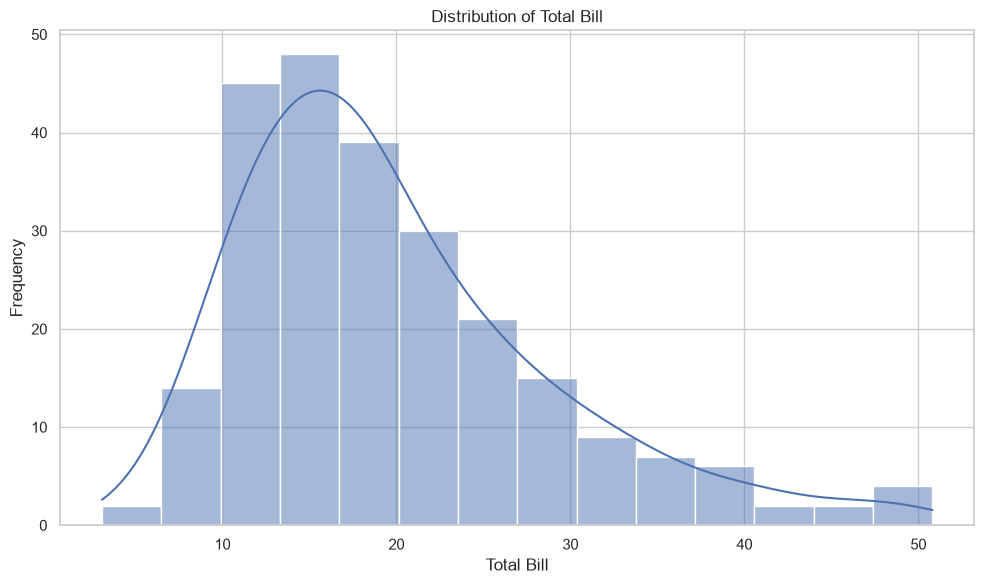

Plot saved successfully to: ..\plots\day02_total_bill_distribution.png


In [17]:
from pathlib import Path

plots_dir = Path("../plots")
plots_dir.mkdir(parents=True, exist_ok=True)

plt.figure(figsize=(10, 6))

sns.histplot(
    df["total_bill"],
    kde=True
)

plt.title("Distribution of Total Bill")
plt.xlabel("Total Bill")
plt.ylabel("Frequency")

plt.tight_layout()

plot_file = plots_dir / "day02_total_bill_distribution.png"
plt.savefig(plot_file, dpi=300, bbox_inches="tight")

plt.show()

print(f"Plot saved successfully to: {plot_file}")

In [10]:
total_bill = df["total_bill"].dropna()

shapiro_stat, shapiro_p = stats.shapiro(total_bill)

print("Shapiro-Wilk Normality Test")
print("---------------------------")
print(f"Statistic: {shapiro_stat:.4f}")
print(f"p-value: {shapiro_p:.6f}")

Shapiro-Wilk Normality Test
---------------------------
Statistic: 0.9197
p-value: 0.000000


In [11]:
alpha = 0.05

if shapiro_p < alpha:
    print("Decision: Reject H₀")
    print("Conclusion: There is evidence that total_bill is not normally distributed.")
else:
    print("Decision: Fail to reject H₀")
    print("Conclusion: There is insufficient evidence to conclude that total_bill is not normally distributed.")

Decision: Reject H₀
Conclusion: There is evidence that total_bill is not normally distributed.


In [12]:
standardized_bill = (
    total_bill - total_bill.mean()
) / total_bill.std(ddof=1)

ks_stat, ks_p = stats.kstest(
    standardized_bill,
    "norm"
)

print("Kolmogorov-Smirnov Normality Test")
print("---------------------------------")
print(f"Statistic: {ks_stat:.4f}")
print(f"p-value: {ks_p:.6f}")

Kolmogorov-Smirnov Normality Test
---------------------------------
Statistic: 0.1188
p-value: 0.001866


In [13]:
if ks_p < alpha:
    print("Decision: Reject H₀")
    print("Conclusion: There is evidence that total_bill is not normally distributed.")
else:
    print("Decision: Fail to reject H₀")
    print("Conclusion: There is insufficient evidence to conclude that total_bill is not normally distributed.")

Decision: Reject H₀
Conclusion: There is evidence that total_bill is not normally distributed.


In [14]:
normality_results = pd.DataFrame({
    "Test": [
        "Shapiro-Wilk",
        "Kolmogorov-Smirnov"
    ],
    "Variable": [
        "total_bill",
        "total_bill"
    ],
    "Statistic": [
        shapiro_stat,
        ks_stat
    ],
    "p_value": [
        shapiro_p,
        ks_p
    ],
    "Alpha": [
        alpha,
        alpha
    ],
    "Decision": [
        "Reject H0" if shapiro_p < alpha else "Fail to reject H0",
        "Reject H0" if ks_p < alpha else "Fail to reject H0"
    ]
})

normality_results

,Test,Variable,Statistic,p_value,Alpha,Decision
0,Shapiro-Wilk,total_bill,0.919719,3.324539e-10,0.05,Reject H0
1,Kolmogorov-Smirnov,total_bill,0.118754,1.866364e-03,0.05,Reject H0


In [15]:
from pathlib import Path

results_dir = Path("../results")
results_dir.mkdir(parents=True, exist_ok=True)

output_file = results_dir / "day02_normality_results.csv"

normality_results.to_csv(output_file, index=False)

print(f"Results saved successfully to: {output_file}")

Results saved successfully to: ..\results\day02_normality_results.csv


In [16]:
saved_results = pd.read_csv("../results/day02_normality_results.csv")

print("Saved results:")
print(saved_results)

Saved results:
                 Test    Variable  Statistic       p_value  Alpha   Decision
0        Shapiro-Wilk  total_bill   0.919719  3.324539e-10   0.05  Reject H0
1  Kolmogorov-Smirnov  total_bill   0.118754  1.866364e-03   0.05  Reject H0
